In [1]:
########### THIS IS A MODEL THAT USES SINDY FOR COVID-19 MODELLING, IT CAN MAKE WEEKLY PROJECTION ##########
###### THIS CODE HELPS YOU TO GENERATE THE FIGURE 5, PLEASE RUN THE CELLS IN ORDER ##########################
####### The code is repeated in the cells, so that you can keep track of instructions #####################


####### Importing the required packages #######
using DataFrames
using CSV
using Plots
using ModelingToolkit, OrdinaryDiffEq, LinearAlgebra
using DifferentialEquations
using DataDrivenDiffEq
using DataDrivenSparse
using StatsPlots
using Statistics
using Distributions
using Dates
using DSP
using RecursiveArrayTools
using DiffEqParamEstim
using Optimization, OptimizationOptimJL
using OptimizationBBO
using ForwardDiff
using PenaltyFunctions
using Turing
using StableRNGs
using DataInterpolations
using ComponentArrays
using StatsBase
using Random

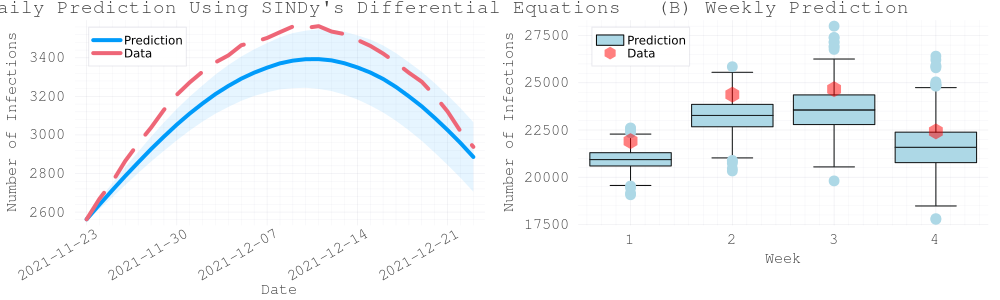

GKS: could not find font Arial.ttf


In [2]:
############### An example for 30 days ###########################################################

#################### Making the Data for 30 days projection #######################################
theme(:bright)

start_training=350
finish_training=680
##### specify the range you want to chop out for prediction
split_start= 630
split_finish=660

begin
    #707 days are recorded
    raw_data=CSV.File("Thuringen_SIRD_2.csv") |> DataFrame
    data=Matrix(raw_data[:,[2, 3]])'
      
    s=size(data)[2]
    for i in 1:s
        data[1,i]=mean(data[1,max(1,i-4):min(s,i)])
    end
    ############# Beta distribution

    function factors(α, β, n) ## Beta distribution, coefficients for n days needed (Infected)
        d=Beta(α, β)
        max=pdf(d, mode(d))
        step=1/(n+2-1)
        steps=collect(0.0:step: 1.0)
        coefs=zeros(length(steps))
        for i in eachindex(coefs)
            coefs[i]=pdf(d,steps[i])/max
        end
        return steps[2:end-1], coefs[2:end-1]
    end

    n=21  #### number of days that infection rate of each patient changes
    vals, cofs=factors(2.5,4.5,n) #### α=1.5 and β=2.5, we can change the curve shape by changing α and β

    infectiveness=zeros(size(data)[2],1);
    infectiveness=conv(cofs, data[1,:])[1:length(infectiveness)]
   
    #smoothing the infectiveness
    for i in eachindex(infectiveness)
        infectiveness[i]=mean(infectiveness[max(i-7,1):min(end, i)])
    end

  
    data1=copy(data)
    data1[2,:]=infectiveness
    Max_data1=[maximum(data1[i,1:end]) for i in 1:size(data1)[1]]
    Min=0#minimum(data)
    for i in 1:size(data1)[1]
        for j in 1:size(data1)[2]
            data1[i,j]=(data1[i,j]-Min)/(Max_data1[i]-Min)
        end
    end 
    
  
    data2=data1[:,start_training:split_start]
    data3=data1[:,split_finish:finish_training]
  
    X1=copy(data2)
    X2=copy(data3)
end

############################# Making control signal for 30 days projection ########################
begin
    v_raw_data=CSV.File("Thuringen_daily_vaccination.csv") |> DataFrame
    v_data=Matrix{Float64}(v_raw_data[:,3:5])'

   
    ####  weekly averaging
    avg_days = 6
    s=size(v_data)
    weekly=Matrix{Float64}(undef,s[1], s[2])
    for i in 1:size(v_data)[1]
        weekly[i,:]=[mean(v_data[i, max(j-avg_days,1):min(j, s[2])]) for j in 1:s[2]]'
    end
   
    ############# beta distribution  

    n=35 ## number of days needed to reach the peak of antibody and then goes down after vaccination
    vvals, vcofs=factors(3,4,n) #### α=3 and β=4, we can change the curve shape by changing α and β
    


    ###############################  factors should be reversed and used ######################
    dose1=zeros(size(v_data)[2],1);
    dose2=zeros(size(v_data)[2],1);
    dose3=zeros(size(v_data)[2],1);

    vcofs1=reverse(reverse(vcofs))
    for i in 1:lastindex(dose1)
        for j in 1:min(n,i)-1
            dose1[i]=dose1[i] + weekly[1, i-j] * vcofs1[j]
            dose2[i]=dose2[i] + weekly[2, i-j] * vcofs1[j]
            dose3[i]=dose3[i] + weekly[3, i-j] * vcofs1[j]
        end 
    end

    dose11=zeros(size(raw_data)[1],1);
    dose21=zeros(size(raw_data)[1],1);
    dose31=zeros(size(raw_data)[1],1);

    difference=Dates.value(v_raw_data[1,1]-raw_data[1,1])
    
    for i in difference+1:lastindex(dose11)
        dose11[i]=dose1[i-difference]
        dose21[i]=dose2[i-difference]
        dose31[i]=dose3[i-difference]
    end

  
    antibody=dose11.+dose21.+ dose31

    Max_antibody=maximum(antibody)
    Min=0#minimum(v_data)
    for i in 1:size(antibody)[1]       
        antibody[i]=(antibody[i]-Min)/(Max_antibody-Min)
    end

    control=vcat(antibody') ### used in prediction
    control1=vcat(antibody[start_training:split_start]')
    control2=vcat(antibody[split_finish:finish_training]')
    
end

######################## definition and solving of the problem ##################
begin
    tick=100_000
   
    t1=collect(0.0:1/tick:(split_start-start_training)/tick);
    itp_method=InterpolationMethod(LinearInterpolation)
   
    t2=collect(0.0:1/tick:(finish_training-split_finish)/tick);
    
    final_data=(prob1=(X=X1, t=t1, itp_method, U=control1), prob2=(X=X2, t=t2,  itp_method, U=control2))
    sir_problem=ContinuousDataset(final_data)#(sir_problem1, sir_problem2

    @variables u[1:2] c[1:1]
    u = collect(u)
    c = collect(c)

    if start_training==1
        h = Num[polynomial_basis([u; c], 1);]# exp(c[1]);exp(c[2]);exp(c[3]);]
   
    else
        h = Num[polynomial_basis([u; c], 2);]
   
    end

    basis = Basis(h, u, controls=c)


    ### choosing STLSQ as an optimizer
    ### STLSQ is a sparsifying algorithm that cause the solve function to call its "Sindy" method ###
    opt = STLSQ(exp10.(-5:0.01:-1))


    #sampler = DataProcessing(split = 0.95, shuffle=true, batchsize = 70, rng = rng)

    options = DataDrivenCommonOptions(maxiters = 10_000,
                                  normalize = DataNormalization(ZScoreTransform),
                                  selector = bic, digits = 3)

    ddsol = solve(sir_problem, basis, opt, options=options)
   
end

################## recovering the dynamic########################
begin
    ##### range of prediction ####
    newdays=0
    start=split_start+newdays
    finish=split_finish
    
    
    res=ddsol
    sys = get_basis(res)

    # Optimal parameters
    p_opt = get_parameter_values(sys)
    
    z0=data1[:,start]#X1[:,end]#data1[:,start]
    z01=data1[:,start]

    ztspan=(start/tick,finish/tick)


    u=control
    tsteps = range(0.0, 706/tick, length = 707)
    A=LinearInterpolation(u,tsteps);


    function get_dose1(t)
        return A(t)[1]
    end


    function get_total_antibody(t)
        down=control[1, Int(round(t*tick+1, RoundDown))]
        up=control[1, Int(round(t*tick+1, RoundUp))]
        down_co=t*tick-round(t*tick,RoundDown)
        up_co=1-down_co
        control_in_t=down_co*down+up_co*up
        return control_in_t

    end

    # Generate a closure on the system 
    f_recovered = let doese_1 = get_dose1
       (x, p, t) -> sys(x, p, t, [doese_1.(t)])   
    end
    f_recovered1 = let doese_1 = get_total_antibody
        (x, p, t) -> sys(x, p.+p_opt, t, [doese_1.(t)])
    end
end

#################### stochastic #########################
begin
    theme(:bright)
    raw_data_end=CSV.File("Thuringen_SIRD_raw_2.csv") |> DataFrame
    data_end=Matrix(raw_data_end[:,[2, 3]])'
    t_step=1/tick
    beta=3
    
    g(u,p,t)=beta*u   #### stochastic function and its parameters

    ################## StatsPlots ################
    y1 = fill(NaN, finish-start+1, 1000);
    y2 = fill(NaN, finish-start+1, 1000);
   
    for i  in 1:1000
        prediction_prob = SDEProblem(f_recovered, g, z0, ztspan, p_opt)
        prediction = solve(prediction_prob, EM(), dt=t_step)
        M=Matrix(prediction)

      
        y1[:,i]=max.(M[1,:].-(z01[1]-data1[1,start]),0)
       
        y2[:,i]=M[2,:]
       
    end
    ptest1=errorline(1:finish-start+1, y1[:,:]*Max_data1[1], errorstyle=:ribbon, label="Prediction", 
                     lw=4, left_margin = 5Plots.mm, bottom_margin = 5Plots.mm, ylabel="Number of Infections",
                     titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), 
                     ytickfont=font(8, "Arial"), xtickfont=font(8, "Arial"))
    plot!(ptest1,data1[1,start:finish]*Max_data1[1], label="Data", lw=4, ls=:dash, title="(A) Daily Prediction Using SINDy's Differential Equations", legend=:topleft)
    dates=raw_data[start:finish,1]
    plot!(ptest1,xformatter= x->Dates.format(dates[Int(round(x+1, RoundDown))], "yyyy-mm-dd"), xrot=30, xlabel="Date", 
            xticks=1:7:finish-start+1,  xminorticks = 7)

    #################### weekly prediction #######################

    test=[]
    d=[]
    xt=Int[]
    c=0
    for i in 1:finish-start+1
        if i%7==0
            test1=y1[i,:].*7*Max_data1[1]
            push!(test, test1)
            d1=data1[1,start+i-1].*7*Max_data1[1]
            push!(d,d1)
            c=c+1
            push!(xt, c)
        end
    end
    p1=boxplot(test, xlabel="Week", ylabel="Number of Infections", label=["Prediction" false false false false false false false], color="lightblue", lw=1,
                titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), bottom_margin = 5Plots.mm,
                ytickfont=font(8, "Arial"), xtickfont=font(8, "Arial"),  xminorticks = 7)
    scatter!(p1,d,m=(0.5, :hex, 8), label="Data", color=:red, title="(B) Weekly Prediction")

    xticks!(p1,xt)
    ########### plotting both results
    plot(ptest1,p1, size=(1000,300), left_margin = 5Plots.mm, bottom_margin = 10Plots.mm,
                titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), 
                ytickfont=font(8,"Arial"), xtickfont=font(8, "Arial"))
end

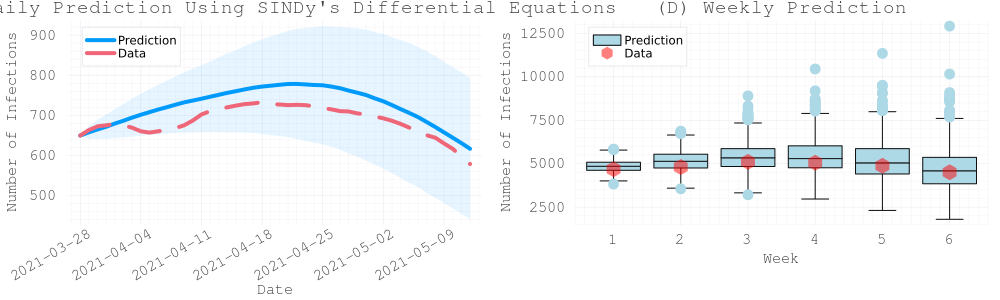

In [6]:
############### An example for 45 days ###########################################################

#################### Making the Data for 45 days projection #######################################
theme(:bright)

##### specify the range you want to chop out for prediction
split_start= 390
split_finish=435

begin
    #707 days are recorded
    raw_data=CSV.File("Thuringen_SIRD_2.csv") |> DataFrame
    data=Matrix(raw_data[:,[2, 3]])'
      
    s=size(data)[2]
    for i in 1:s
        data[1,i]=mean(data[1,max(1,i-4):min(s,i)])
    end
    ############# Beta distribution

    function factors(α, β, n) ## Beta distribution, coefficients for n days needed (Infected)
        d=Beta(α, β)
        max=pdf(d, mode(d))
        step=1/(n+2-1)
        steps=collect(0.0:step: 1.0)
        coefs=zeros(length(steps))
        for i in eachindex(coefs)
            coefs[i]=pdf(d,steps[i])/max
        end
        return steps[2:end-1], coefs[2:end-1]
    end

    n=21  #### number of days that infection rate of each patient changes
    vals, cofs=factors(2.5,4.5,n) #### α=1.5 and β=2.5, we can change the curve shape by changing α and β

    infectiveness=zeros(size(data)[2],1);
    infectiveness=conv(cofs, data[1,:])[1:length(infectiveness)]
   
    #smoothing the infectiveness
    for i in eachindex(infectiveness)
        infectiveness[i]=mean(infectiveness[max(i-7,1):min(end, i)])
    end

  
    data1=copy(data)
    data1[2,:]=infectiveness
    Max_data1=[maximum(data1[i,1:end]) for i in 1:size(data1)[1]]
    Min=0#minimum(data)
    for i in 1:size(data1)[1]
        for j in 1:size(data1)[2]
            data1[i,j]=(data1[i,j]-Min)/(Max_data1[i]-Min)
        end
    end 
    
  
    data2=data1[:,start_training:split_start]
    data3=data1[:,split_finish:finish_training]
  
    X1=copy(data2)
    X2=copy(data3)
end

############################# Making control signal for 30 days projection ########################
begin
    v_raw_data=CSV.File("Thuringen_daily_vaccination.csv") |> DataFrame
    v_data=Matrix{Float64}(v_raw_data[:,3:5])'

   
    ####  weekly averaging
    avg_days = 6
    s=size(v_data)
    weekly=Matrix{Float64}(undef,s[1], s[2])
    for i in 1:size(v_data)[1]
        weekly[i,:]=[mean(v_data[i, max(j-avg_days,1):min(j, s[2])]) for j in 1:s[2]]'
    end
   
    ############# beta distribution  

    n=35 ## number of days needed to reach the peak of antibody and then goes down after vaccination
    vvals, vcofs=factors(3,4,n) #### α=3 and β=4, we can change the curve shape by changing α and β
    


    ###############################  factors should be reversed and used ######################
    dose1=zeros(size(v_data)[2],1);
    dose2=zeros(size(v_data)[2],1);
    dose3=zeros(size(v_data)[2],1);

    vcofs1=reverse(reverse(vcofs))
    for i in 1:lastindex(dose1)
        for j in 1:min(n,i)-1
            dose1[i]=dose1[i] + weekly[1, i-j] * vcofs1[j]
            dose2[i]=dose2[i] + weekly[2, i-j] * vcofs1[j]
            dose3[i]=dose3[i] + weekly[3, i-j] * vcofs1[j]
        end 
    end

    dose11=zeros(size(raw_data)[1],1);
    dose21=zeros(size(raw_data)[1],1);
    dose31=zeros(size(raw_data)[1],1);

    difference=Dates.value(v_raw_data[1,1]-raw_data[1,1])
    
    for i in difference+1:lastindex(dose11)
        dose11[i]=dose1[i-difference]
        dose21[i]=dose2[i-difference]
        dose31[i]=dose3[i-difference]
    end

  
    antibody=dose11.+dose21.+ dose31

    Max_antibody=maximum(antibody)
    Min=0#minimum(v_data)
    for i in 1:size(antibody)[1]       
        antibody[i]=(antibody[i]-Min)/(Max_antibody-Min)
    end

    control=vcat(antibody') ### used in prediction
    control1=vcat(antibody[start_training:split_start]')
    control2=vcat(antibody[split_finish:finish_training]')
    
end

######################## definition and solving of the problem ##################
begin
    tick=100_000
   
    t1=collect(0.0:1/tick:(split_start-start_training)/tick);
    itp_method=InterpolationMethod(LinearInterpolation)
   
    t2=collect(0.0:1/tick:(finish_training-split_finish)/tick);
    
    final_data=(prob1=(X=X1, t=t1, itp_method, U=control1), prob2=(X=X2, t=t2,  itp_method, U=control2))
    sir_problem=ContinuousDataset(final_data)#(sir_problem1, sir_problem2

    @variables u[1:2] c[1:1]
    u = collect(u)
    c = collect(c)

    if start_training==1
        h = Num[polynomial_basis([u; c], 1);]# exp(c[1]);exp(c[2]);exp(c[3]);]
   
    else
        h = Num[polynomial_basis([u; c], 2);]
   
    end

    basis = Basis(h, u, controls=c)


    ### choosing STLSQ as an optimizer
    ### STLSQ is a sparsifying algorithm that cause the solve function to call its "Sindy" method ###
    opt = STLSQ(exp10.(-5:0.01:-1))


    #sampler = DataProcessing(split = 0.95, shuffle=true, batchsize = 70, rng = rng)

    options = DataDrivenCommonOptions(maxiters = 10_000,
                                  normalize = DataNormalization(ZScoreTransform),
                                  selector = bic, digits = 3)

    ddsol = solve(sir_problem, basis, opt, options=options)
   
end

################## recovering the dynamic########################
begin
    ##### range of prediction ####
    newdays=0
    start=split_start+newdays
    finish=split_finish
    
    
    res=ddsol
    sys = get_basis(res)

    # Optimal parameters
    p_opt = get_parameter_values(sys)
    
    z0=data1[:,start]#X1[:,end]#data1[:,start]
    z01=data1[:,start]

    ztspan=(start/tick,finish/tick)


    u=control
    tsteps = range(0.0, 706/tick, length = 707)
    A=LinearInterpolation(u,tsteps);


    function get_dose1(t)
        return A(t)[1]
    end


    function get_total_antibody(t)
        down=control[1, Int(round(t*tick+1, RoundDown))]
        up=control[1, Int(round(t*tick+1, RoundUp))]
        down_co=t*tick-round(t*tick,RoundDown)
        up_co=1-down_co
        control_in_t=down_co*down+up_co*up
        return control_in_t

    end

    # Generate a closure on the system 
    f_recovered = let doese_1 = get_dose1
       (x, p, t) -> sys(x, p, t, [doese_1.(t)])   
    end
    f_recovered1 = let doese_1 = get_total_antibody
        (x, p, t) -> sys(x, p.+p_opt, t, [doese_1.(t)])
    end
end

#################### stochastic #########################
begin
    theme(:bright)
    raw_data_end=CSV.File("Thuringen_SIRD_raw_2.csv") |> DataFrame
    data_end=Matrix(raw_data_end[:,[2, 3]])'
    t_step=1/tick
    beta=8
    
    g(u,p,t)=beta*u   #### stochastic function and its parameters

    ################## StatsPlots ################
    y1 = fill(NaN, finish-start+1, 1000);
    y2 = fill(NaN, finish-start+1, 1000);
   
    for i  in 1:1000
        prediction_prob = SDEProblem(f_recovered, g, z0, ztspan, p_opt)
        prediction = solve(prediction_prob, EM(), dt=t_step)
        M=Matrix(prediction)

      
        y1[:,i]=max.(M[1,:].-(z01[1]-data1[1,start]),0)
       
        y2[:,i]=M[2,:]
       
    end
    ptest2=errorline(1:finish-start+1, y1[:,:]*Max_data1[1], errorstyle=:ribbon, label="Prediction", 
                     lw=4, left_margin = 5Plots.mm, bottom_margin = 5Plots.mm, ylabel="Number of Infections",
                     titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), 
                     ytickfont=font(8, "Arial"), xtickfont=font(8, "Arial"))
    plot!(ptest2,data1[1,start:finish]*Max_data1[1], label="Data", lw=4, ls=:dash, title="(C) Daily Prediction Using SINDy's Differential Equations", legend=:topleft)
    dates=raw_data[start:finish,1]
    plot!(ptest2,xformatter= x->Dates.format(dates[Int(round(x+1, RoundDown))], "yyyy-mm-dd"), xrot=30, xlabel="Date", 
            xticks=1:7:finish-start+1,  xminorticks = 7)

    #################### weekly prediction #######################

    test=[]
    d=[]
    xt=Int[]
    c=0
    for i in 1:finish-start+1
        if i%7==0
            test1=y1[i,:].*7*Max_data1[1]
            push!(test, test1)
            d1=data1[1,start+i-1].*7*Max_data1[1]
            push!(d,d1)
            c=c+1
            push!(xt, c)
        end
    end
    p2=boxplot(test, xlabel="Week", ylabel="Number of Infections", label=["Prediction" false false false false false false false], color="lightblue", lw=1,
                titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), bottom_margin = 5Plots.mm,
                ytickfont=font(8, "Arial"), xtickfont=font(8, "Arial"),  xminorticks = 7)
    scatter!(p2,d,m=(0.5, :hex, 8), label="Data", color=:red, title="(D) Weekly Prediction")

    xticks!(p2,xt)
    ########### plotting both results
    plot(ptest2,p2, size=(1000,300), left_margin = 5Plots.mm, bottom_margin = 10Plots.mm,
                titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), 
                ytickfont=font(8,"Arial"), xtickfont=font(8, "Arial"))
end

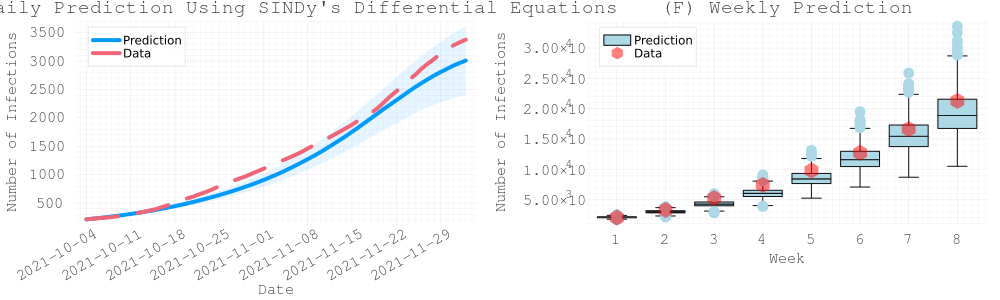

In [7]:
############### An example for 60 days ###########################################################

#################### Making the Data for 60 days projection #######################################
theme(:bright)

split_start= 580
split_finish=640

begin
    #707 days are recorded
    raw_data=CSV.File("Thuringen_SIRD_2.csv") |> DataFrame
    data=Matrix(raw_data[:,[2, 3]])'
      
    s=size(data)[2]
    for i in 1:s
        data[1,i]=mean(data[1,max(1,i-4):min(s,i)])
    end
    ############# Beta distribution

    function factors(α, β, n) ## Beta distribution, coefficients for n days needed (Infected)
        d=Beta(α, β)
        max=pdf(d, mode(d))
        step=1/(n+2-1)
        steps=collect(0.0:step: 1.0)
        coefs=zeros(length(steps))
        for i in eachindex(coefs)
            coefs[i]=pdf(d,steps[i])/max
        end
        return steps[2:end-1], coefs[2:end-1]
    end

    n=21  #### number of days that infection rate of each patient changes
    vals, cofs=factors(2.5,4.5,n) #### α=1.5 and β=2.5, we can change the curve shape by changing α and β

    infectiveness=zeros(size(data)[2],1);
    infectiveness=conv(cofs, data[1,:])[1:length(infectiveness)]
   
    #smoothing the infectiveness
    for i in eachindex(infectiveness)
        infectiveness[i]=mean(infectiveness[max(i-7,1):min(end, i)])
    end

  
    data1=copy(data)
    data1[2,:]=infectiveness
    Max_data1=[maximum(data1[i,1:end]) for i in 1:size(data1)[1]]
    Min=0
    for i in 1:size(data1)[1]
        for j in 1:size(data1)[2]
            data1[i,j]=(data1[i,j]-Min)/(Max_data1[i]-Min)
        end
    end 
    
  
    data2=data1[:,start_training:split_start]
    data3=data1[:,split_finish:finish_training]
  
    X1=copy(data2)
    X2=copy(data3)
end

############################# Making control signal for 30 days projection ########################
begin
    v_raw_data=CSV.File("Thuringen_daily_vaccination.csv") |> DataFrame
    v_data=Matrix{Float64}(v_raw_data[:,3:5])'

   
    ####  weekly averaging
    avg_days = 6
    s=size(v_data)
    weekly=Matrix{Float64}(undef,s[1], s[2])
    for i in 1:size(v_data)[1]
        weekly[i,:]=[mean(v_data[i, max(j-avg_days,1):min(j, s[2])]) for j in 1:s[2]]'
    end
   
    ############# beta distribution  

    n=35 ## number of days needed to reach the peak of antibody and then goes down after vaccination
    vvals, vcofs=factors(3,4,n) #### α=3 and β=4, we can change the curve shape by changing α and β
    


    ###############################  factors should be reversed and used ######################
    dose1=zeros(size(v_data)[2],1);
    dose2=zeros(size(v_data)[2],1);
    dose3=zeros(size(v_data)[2],1);

    vcofs1=reverse(reverse(vcofs))
    for i in 1:lastindex(dose1)
        for j in 1:min(n,i)-1
            dose1[i]=dose1[i] + weekly[1, i-j] * vcofs1[j]
            dose2[i]=dose2[i] + weekly[2, i-j] * vcofs1[j]
            dose3[i]=dose3[i] + weekly[3, i-j] * vcofs1[j]
        end 
    end

    dose11=zeros(size(raw_data)[1],1);
    dose21=zeros(size(raw_data)[1],1);
    dose31=zeros(size(raw_data)[1],1);

    difference=Dates.value(v_raw_data[1,1]-raw_data[1,1])
    
    for i in difference+1:lastindex(dose11)
        dose11[i]=dose1[i-difference]
        dose21[i]=dose2[i-difference]
        dose31[i]=dose3[i-difference]
    end

  
    antibody=dose11.+dose21.+ dose31

    Max_antibody=maximum(antibody)
    Min=0
    for i in 1:size(antibody)[1]       
        antibody[i]=(antibody[i]-Min)/(Max_antibody-Min)
    end

    control=vcat(antibody') ### used in prediction
    control1=vcat(antibody[start_training:split_start]')
    control2=vcat(antibody[split_finish:finish_training]')
    
end

######################## definition and solving of the problem ##################
begin
    tick=100_000
   
    t1=collect(0.0:1/tick:(split_start-start_training)/tick);
    itp_method=InterpolationMethod(LinearInterpolation)
   
    t2=collect(0.0:1/tick:(finish_training-split_finish)/tick);
    
    final_data=(prob1=(X=X1, t=t1, itp_method, U=control1), prob2=(X=X2, t=t2,  itp_method, U=control2))
    sir_problem=ContinuousDataset(final_data)#(sir_problem1, sir_problem2

    @variables u[1:2] c[1:1]
    u = collect(u)
    c = collect(c)

    if start_training==1
        h = Num[polynomial_basis([u; c], 1);]# exp(c[1]);exp(c[2]);exp(c[3]);]
   
    else
        h = Num[polynomial_basis([u; c], 2);]
   
    end

    basis = Basis(h, u, controls=c)


    ### choosing STLSQ as an optimizer
    ### STLSQ is a sparsifying algorithm that cause the solve function to call its "Sindy" method ###
    opt = STLSQ(exp10.(-5:0.01:-1))



    options = DataDrivenCommonOptions(maxiters = 10_000,
                                  normalize = DataNormalization(ZScoreTransform),
                                  selector = bic, digits = 3)

    ddsol = solve(sir_problem, basis, opt, options=options)
   
end

################## recovering the dynamic########################
begin
    ##### range of prediction ####
    newdays=0
    start=split_start+newdays
    finish=split_finish
    
    
    res=ddsol
    sys = get_basis(res)

    # Optimal parameters
    p_opt = get_parameter_values(sys)
    
    z0=data1[:,start]

    ztspan=(start/tick,finish/tick)


    u=control
    tsteps = range(0.0, 706/tick, length = 707)
    A=LinearInterpolation(u,tsteps);


    function get_dose1(t)
        return A(t)[1]
    end


    function get_total_antibody(t)
        down=control[1, Int(round(t*tick+1, RoundDown))]
        up=control[1, Int(round(t*tick+1, RoundUp))]
        down_co=t*tick-round(t*tick,RoundDown)
        up_co=1-down_co
        control_in_t=down_co*down+up_co*up
        return control_in_t

    end

    # Generate a closure on the system 
    f_recovered = let doese_1 = get_dose1
       (x, p, t) -> sys(x, p, t, [doese_1.(t)])   
    end
    f_recovered1 = let doese_1 = get_total_antibody
        (x, p, t) -> sys(x, p.+p_opt, t, [doese_1.(t)])
    end
end

#################### stochastic #########################
begin
    theme(:bright)
    raw_data_end=CSV.File("Thuringen_SIRD_raw_2.csv") |> DataFrame
    data_end=Matrix(raw_data_end[:,[2, 3]])'
    t_step=1/tick
    beta=8
    
    g(u,p,t)=beta*u   #### stochastic function and its parameters

    ################## StatsPlots ################
    y1 = fill(NaN, finish-start+1, 1000);
    y2 = fill(NaN, finish-start+1, 1000);
   
    for i  in 1:1000
        prediction_prob = SDEProblem(f_recovered, g, z0, ztspan, p_opt)
        prediction = solve(prediction_prob, EM(), dt=t_step)
        M=Matrix(prediction)

      
        y1[:,i]=max.(M[1,:].-(z0[1]-data1[1,start]),0)
       
        y2[:,i]=M[2,:]
       
    end
    ptest3=errorline(1:finish-start+1, y1[:,:]*Max_data1[1], errorstyle=:ribbon, label="Prediction", 
                     lw=4, left_margin = 5Plots.mm, bottom_margin = 5Plots.mm, ylabel="Number of Infections",
                     titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), 
                     ytickfont=font(8, "Arial"), xtickfont=font(8, "Arial"))
    plot!(ptest3,data1[1,start:finish]*Max_data1[1], label="Data", lw=4, ls=:dash, title="(E) Daily Prediction Using SINDy's Differential Equations", legend=:topleft)
    dates=raw_data[start:finish,1]
    plot!(ptest3,xformatter= x->Dates.format(dates[Int(round(x+1, RoundDown))], "yyyy-mm-dd"), xrot=30, xlabel="Date", 
            xticks=1:7:finish-start+1,  xminorticks = 7)

    #################### weekly prediction #######################

    test=[]
    d=[]
    xt=Int[]
    c=0
    for i in 1:finish-start+1
        if i%7==0
            test1=y1[i,:].*7*Max_data1[1]
            push!(test, test1)
            d1=data1[1,start+i-1].*7*Max_data1[1]
            push!(d,d1)
            c=c+1
            push!(xt, c)
        end
    end
    p3=boxplot(test, xlabel="Week", ylabel="Number of Infections", label=["Prediction" false false false false false false false], color="lightblue", lw=1,
                titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), bottom_margin = 5Plots.mm,
                ytickfont=font(8, "Arial"), xtickfont=font(8, "Arial"),  xminorticks = 7)
    scatter!(p3,d,m=(0.5, :hex, 8), label="Data", color=:red, title="(F) Weekly Prediction")

    xticks!(p3,xt)
    ########### plotting both results
    plot(ptest3,p3, size=(1000,300), left_margin = 5Plots.mm, bottom_margin = 10Plots.mm,
                titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), 
                ytickfont=font(8,"Arial"), xtickfont=font(8, "Arial"))
end

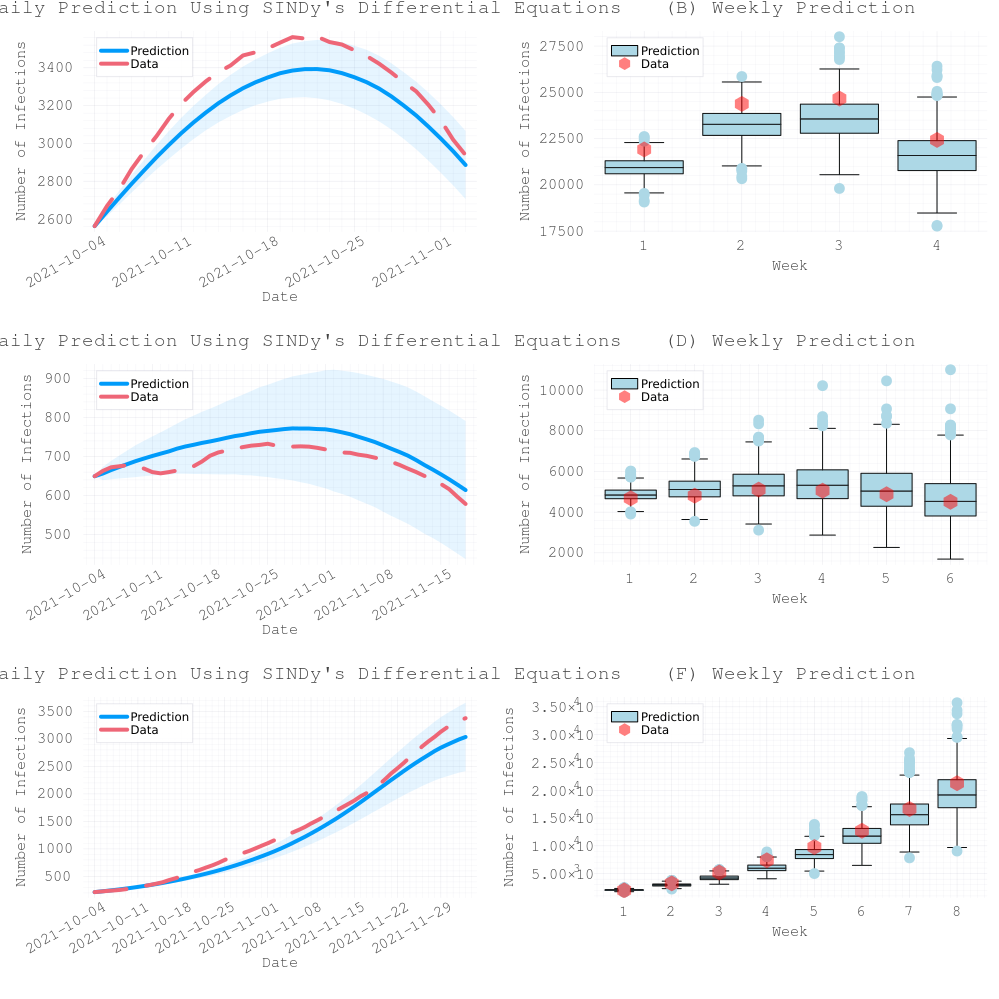

In [5]:
###### The whole figure 5 ####################
l=@layout [[grid(3,2)]]
plot(ptest1, p1, ptest2, p2, ptest3, p3, layout=l,  size=(1000, 1000), left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)